# Object Detection with YOLOv11

**Dataset:** Alien vs Predator — 347 train / 100 val images per class  
**Task:** Fine-tune YOLOv11 for 2-class object detection


In [1]:
import os
import shutil
import random
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
import yaml

In [2]:
DATA_ROOT = Path("data")
CLASSES = ["alien", "predator"]

for split in ("train", "validation"):
    for cls in CLASSES:
        imgs = list((DATA_ROOT / split / cls).glob("*.jpg"))
        print(f"{split:>10} / {cls:<10}: {len(imgs)} images")

     train / alien     : 347 images
     train / predator  : 347 images
validation / alien     : 100 images
validation / predator  : 100 images


## Sample Images


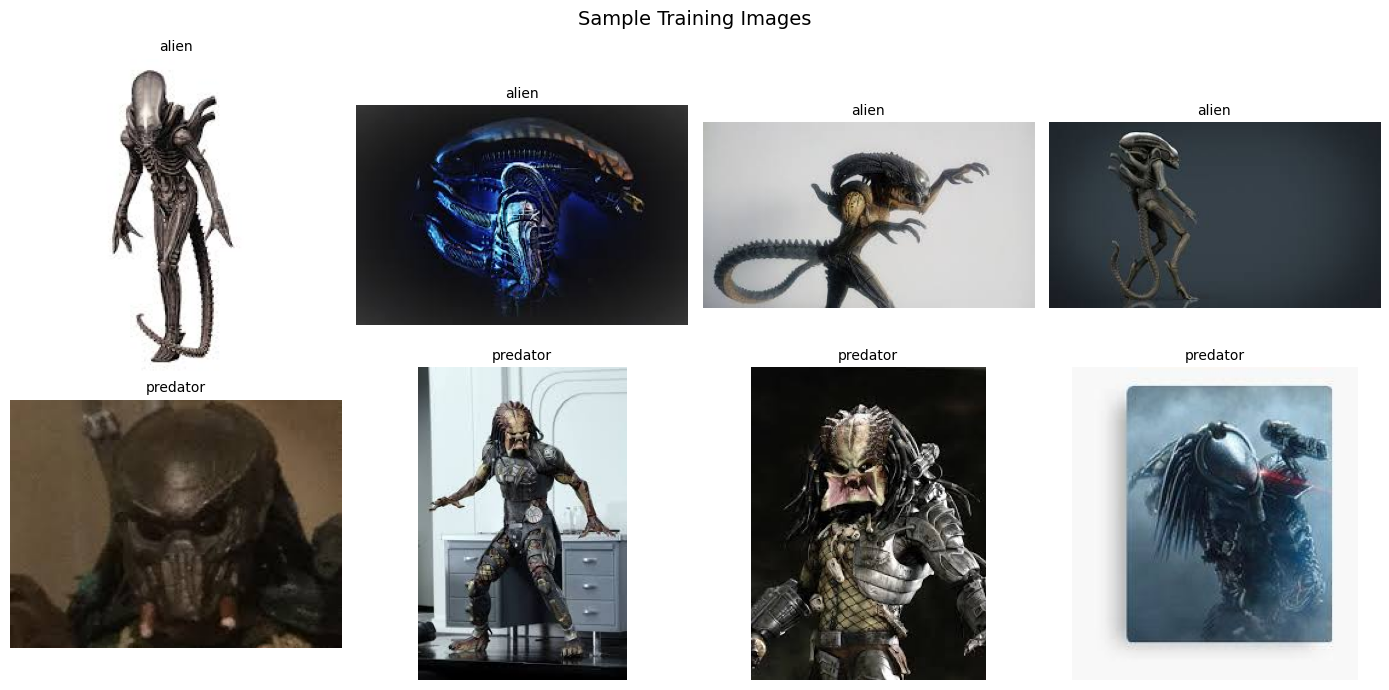

In [3]:
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
fig.suptitle("Sample Training Images", fontsize=14)

for row, cls in enumerate(CLASSES):
    imgs = list((DATA_ROOT / "train" / cls).glob("*.jpg"))
    samples = random.sample(imgs, 4)
    for col, path in enumerate(samples):
        img = cv2.cvtColor(cv2.imread(str(path)), cv2.COLOR_BGR2RGB)
        axes[row, col].imshow(img)
        axes[row, col].set_title(cls, fontsize=10)
        axes[row, col].axis("off")

plt.tight_layout()
plt.show()

## Convert to YOLO Detection Format

YOLO detection needs:

```
dataset/
  images/train/   images/val/
  labels/train/   labels/val/
```

Each label `.txt`: `class_id cx cy w h` (normalized 0–1).  
Since images have no bounding-box annotations, we use **whole-image boxes** (`0.5 0.5 1.0 1.0`).


In [4]:
YOLO_ROOT = Path("yolo_dataset")

SPLIT_MAP = {"train": "train", "validation": "val"}

for src_split, dst_split in SPLIT_MAP.items():
    for cls_id, cls_name in enumerate(CLASSES):
        src_dir = DATA_ROOT / src_split / cls_name
        img_dst = YOLO_ROOT / "images" / dst_split
        lbl_dst = YOLO_ROOT / "labels" / dst_split
        img_dst.mkdir(parents=True, exist_ok=True)
        lbl_dst.mkdir(parents=True, exist_ok=True)

        for img_path in src_dir.glob("*.jpg"):
            # unique name to avoid class collisions
            new_name = f"{cls_name}_{img_path.name}"
            shutil.copy(img_path, img_dst / new_name)

            label_file = lbl_dst / new_name.replace(".jpg", ".txt")
            label_file.write_text(f"{cls_id} 0.5 0.5 1.0 1.0\n")

print("Converted dataset:")
for dst_split in ("train", "val"):
    n_img = len(list((YOLO_ROOT / "images" / dst_split).glob("*.jpg")))
    n_lbl = len(list((YOLO_ROOT / "labels" / dst_split).glob("*.txt")))
    print(f"  {dst_split}: {n_img} images, {n_lbl} labels")

Converted dataset:
  train: 694 images, 694 labels
  val: 200 images, 200 labels


## Create `data.yaml`


In [5]:
data_yaml = {
    "path": str(YOLO_ROOT.resolve()),
    "train": "images/train",
    "val": "images/val",
    "nc": len(CLASSES),
    "names": CLASSES,
}

yaml_path = YOLO_ROOT / "data.yaml"
with open(yaml_path, "w") as f:
    yaml.dump(data_yaml, f, default_flow_style=False, sort_keys=False)

print(yaml_path.read_text())

path: C:\Users\jeffr\GitHub\2026-I\CV\S11\lab1\yolo_dataset
train: images/train
val: images/val
nc: 2
names:
- alien
- predator



## Train YOLOv11


In [6]:
from ultralytics import YOLO

model = YOLO("yolo11m.pt")

results = model.train(
    data=str(yaml_path),
    epochs=10,
    imgsz=640,
    batch=16,
    name="alien_predator",
    project="runs/detect",
    exist_ok=True,
    patience=10,
    device="cpu",
)

Ultralytics 8.4.60  Python-3.11.15 torch-2.12.0+cpu CPU (AMD Ryzen 5 4500U with Radeon Graphics)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=yolo_dataset\data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11m.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=alien_predator, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True,

KeyboardInterrupt: 

## Evaluate on Validation Set


In [ ]:
best_weights = Path("runs/detect/alien_predator/weights/best.pt")
trained_model = YOLO(str(best_weights))

metrics = trained_model.val(data=str(yaml_path))

print(f"mAP50     : {metrics.box.map50:.4f}")
print(f"mAP50-95  : {metrics.box.map:.4f}")
print(f"Precision : {metrics.box.mp:.4f}")
print(f"Recall    : {metrics.box.mr:.4f}")

## Training Curves


In [ ]:
import pandas as pd

results_csv = Path("runs/detect/alien_predator/results.csv")
df = pd.read_csv(results_csv)
df.columns = df.columns.str.strip()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Training Curves", fontsize=13)

axes[0].plot(df["epoch"], df["train/box_loss"], label="train")
axes[0].plot(df["epoch"], df["val/box_loss"], label="val")
axes[0].set_title("Box Loss")
axes[0].legend()
axes[0].set_xlabel("Epoch")

axes[1].plot(df["epoch"], df["train/cls_loss"], label="train")
axes[1].plot(df["epoch"], df["val/cls_loss"], label="val")
axes[1].set_title("Class Loss")
axes[1].legend()
axes[1].set_xlabel("Epoch")

axes[2].plot(df["epoch"], df["metrics/mAP50(B)"], label="mAP50")
axes[2].plot(df["epoch"], df["metrics/mAP50-95(B)"], label="mAP50-95")
axes[2].set_title("mAP")
axes[2].legend()
axes[2].set_xlabel("Epoch")

plt.tight_layout()
plt.show()

## Inference & Visualization


In [ ]:
val_imgs = list((YOLO_ROOT / "images" / "val").glob("*.jpg"))
samples = random.sample(val_imgs, min(8, len(val_imgs)))

preds = trained_model.predict(samples, conf=0.25, verbose=False)

COLOR = {"alien": (0, 200, 0), "predator": (200, 0, 0)}

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle("Predictions on Validation Images", fontsize=13)

for ax, (img_path, result) in zip(axes.flat, zip(samples, preds)):
    img = cv2.cvtColor(cv2.imread(str(img_path)), cv2.COLOR_BGR2RGB)

    for box in result.boxes:
        cls_id = int(box.cls)
        conf   = float(box.conf)
        label  = f"{CLASSES[cls_id]} {conf:.2f}"
        x1, y1, x2, y2 = map(int, box.xyxy[0])
        color = COLOR[CLASSES[cls_id]]
        cv2.rectangle(img, (x1, y1), (x2, y2), color, 2)
        cv2.putText(img, label, (x1, max(y1 - 6, 12)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.55, color, 2)

    ax.imshow(img)
    ax.set_title(img_path.stem.split("_")[0], fontsize=9)
    ax.axis("off")

plt.tight_layout()
plt.show()